# Netflix Data Analysis

# Project Overview

This project analyzes the Netflix Movies and TV Shows dataset to understand the platform's content library. The dataset contains information such as content type, title, director, cast, country, release year, date added, rating, duration, and genre. The project involves data cleaning, exploratory data analysis (EDA), and data visualization to identify trends, patterns, and insights about Netflix content.


# Project Objectives

1. To analyze the distribution of Movies and TV Shows available on Netflix.

2. To examine content trends based on release years and the dates when titles were added to Netflix.

3. To identify the most common genres, content ratings, and producing countries on the platform.

4. To explore the duration of Netflix content and understand its overall distribution.

5. To derive meaningful insights and visualize patterns that help understand Netflix's content library.


In [6]:

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# loading the dataset
df = pd.read_csv(r"C:/Users/USER/Downloads/archive (4)/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Initial Data Inspection

In [8]:
# Column Names
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [9]:
# Dataset Dimensions
df.shape

(8807, 12)

In [10]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [11]:
# Missing Value Analysis
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
# Duplicate Value Analysis
duplicates = df.duplicated().sum()
print("Total duplicate rows:", duplicates)

Total duplicate rows: 0


## Key Findings
1.The dataset contains 8,807 records and 12 columns.

2.Most columns are categorical (object), while release_year is stored as an integer.

3.The date_added column is stored as a string (object) and needs to be converted to datetime format for date-based analysis.

4.Missing values are present in the director, cast, country, date_added, rating, and duration columns.

5.No duplicate records were found in the dataset.

# Data Cleaning

In [13]:
# Remove Unnecessary Column
df.drop(columns=['description'], inplace=True)


In [14]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='str')

In [15]:
# Missing Value Percentage
round((df.isnull().sum() / len(df)) * 100, 2)

show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
dtype: float64

In [16]:
# Handle Missing Values in Categorical Columns
df['country'] = df['country'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')

In [17]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
dtype: int64

In [18]:
df[df['date_added'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,Unknown,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas"
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,Unknown,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries
6795,s6796,TV Show,Frasier,Unknown,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies"
6806,s6807,TV Show,Friends,Unknown,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies"
6901,s6902,TV Show,Gunslinger Girl,Unknown,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows"
7196,s7197,TV Show,Kikoriki,Unknown,Igor Dmitriev,Unknown,NaN,2010,TV-Y,2 Seasons,Kids' TV
7254,s7255,TV Show,La Familia P. Luche,Unknown,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaN,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh..."
7406,s7407,TV Show,Maron,Unknown,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies
7847,s7848,TV Show,Red vs. Blue,Unknown,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ..."
8182,s8183,TV Show,The Adventures of Figaro Pho,Unknown,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaN,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies"


In [19]:
# Remove Missing Values from date_added
df.dropna(subset=['date_added'], inplace=True)
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        3
listed_in       0
dtype: int64

In [20]:
df[df['rating'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,Unknown,"Oprah Winfrey, Ava DuVernay",Unknown,"January 26, 2017",2017,NaN,37 min,Movies
6827,s6828,TV Show,Gargantia on the Verdurous Planet,Unknown,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows"
7312,s7313,TV Show,Little Lunch,Unknown,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies"
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas


In [21]:
df[df['duration'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies


In [22]:
# Move the values from rating to duration
df.loc[[5541, 5794, 5813], 'duration'] = df.loc[[5541, 5794, 5813], 'rating']
df[df['duration'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in


In [23]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        0
listed_in       0
dtype: int64

In [24]:
import numpy as np
# Correct Misplaced Values in rating Column
df.loc[[5541, 5794, 5813], 'rating'] = np.nan

In [25]:
df[df['rating'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,NaN,74 min,Movies
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,NaN,84 min,Movies
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,NaN,66 min,Movies
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,Unknown,"Oprah Winfrey, Ava DuVernay",Unknown,"January 26, 2017",2017,NaN,37 min,Movies
6827,s6828,TV Show,Gargantia on the Verdurous Planet,Unknown,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows"
7312,s7313,TV Show,Little Lunch,Unknown,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies"
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas


In [26]:
# Handle Missing Values in rating Column
df['rating'] = df['rating'].fillna('Unknown')
df[df['rating'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in


In [27]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [28]:
# Rename column name
df.rename(columns={
    'listed_in': 'genres',
    'date_added': 'added_date'
}, inplace=True)

In [29]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'added_date',
       'release_year', 'rating', 'duration', 'genres'],
      dtype='str')

### Handling Whitespaces in `added_date`

Some values in the `added_date` column contained leading/trailing whitespaces, causing an error during datetime conversion. The extra spaces were removed using `str.strip()`, and the column was successfully converted to the `datetime` data type.


In [30]:
# Remove leading/trailing whitespaces
df['added_date'] = df['added_date'].str.strip()

# Convert to datetime
df['added_date'] = pd.to_datetime(
    df['added_date'],
    format='%B %d, %Y'
)

In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   str           
 1   type          8797 non-null   str           
 2   title         8797 non-null   str           
 3   director      8797 non-null   str           
 4   cast          8797 non-null   str           
 5   country       8797 non-null   str           
 6   added_date    8797 non-null   datetime64[us]
 7   release_year  8797 non-null   int64         
 8   rating        8797 non-null   str           
 9   duration      8797 non-null   str           
 10  genres        8797 non-null   str           
dtypes: datetime64[us](1), int64(1), str(9)
memory usage: 1.1 MB


In [32]:
df.shape

(8797, 11)

## Cleaning Summary.
- Removed the description column as it was not required for the exploratory data analysis.

- Filled missing values in the country, director, and cast columns with "Unknown".

- Removed rows with missing values in the date_added column.

- Corrected the 3 misplaced values where movie durations had been shifted into the rating column, and restored them to the duration column.

- Replaced missing values in the rating column by first converting invalid entries to NaN and then filling them with "Unknown".

- Renamed columns for better readability:

    listed_in → genres

  
     date_added → added_date

- Removed leading and trailing white spaces from the added_date column.

- Converted the added_date column from string (object) to datetime format for date-based analysis.

After these preprocessing steps, the dataset was cleaned and ready for Exploratory Data Analysis (EDA).

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure, distribution, and patterns in the Netflix dataset. It helps identify trends, relationships, and key insights through statistical summaries and visualizations.


## 1. Movies vs TV Shows Distribution

In [33]:
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

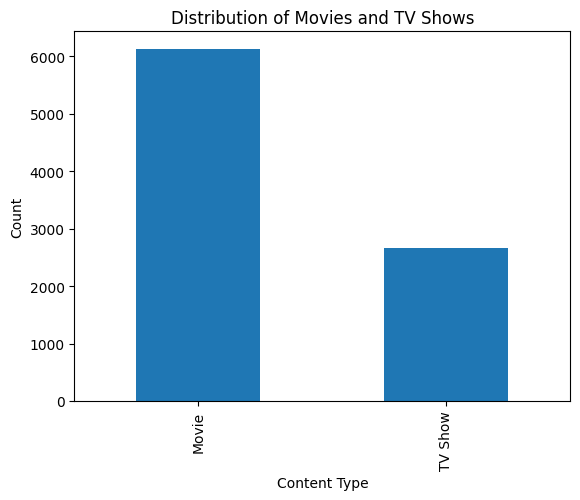

In [34]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')

plt.title('Distribution of Movies and TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

Observation:
The bar chart shows that Movies are more numerous than TV Shows in the Netflix dataset. This indicates that Netflix's content library is primarily composed of movies.

## 2. Content Added Over the Years

In [35]:
# Extract Year from added_date
df['added_year'] = df['added_date'].dt.year

In [36]:
added_year = df['added_year'].value_counts().sort_index()
added_year

added_year
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

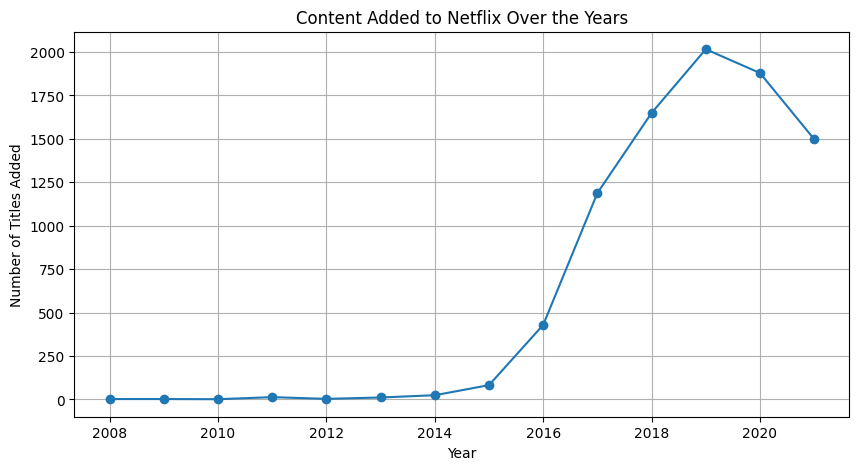

In [37]:
plt.figure(figsize=(10,5))

plt.plot(added_year.index, added_year.values, marker='o')

plt.title('Content Added to Netflix Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')

plt.grid(True)

plt.show()

### Observation

The analysis shows that Netflix added the least amount of content in **2008**, with only **2 titles**. Content additions remained relatively low until **2015**, after which they increased significantly. The number of titles added grew rapidly between **2016 and 2019**, reaching a peak of **2,016 titles in 2019**. After 2019, the number of new additions declined slightly in **2020** and **2021**, but remained substantially higher than in the earlier years.


## 3. Content Release Year Analysis

In [38]:
release_year = df['release_year'].value_counts().sort_index()

release_year

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

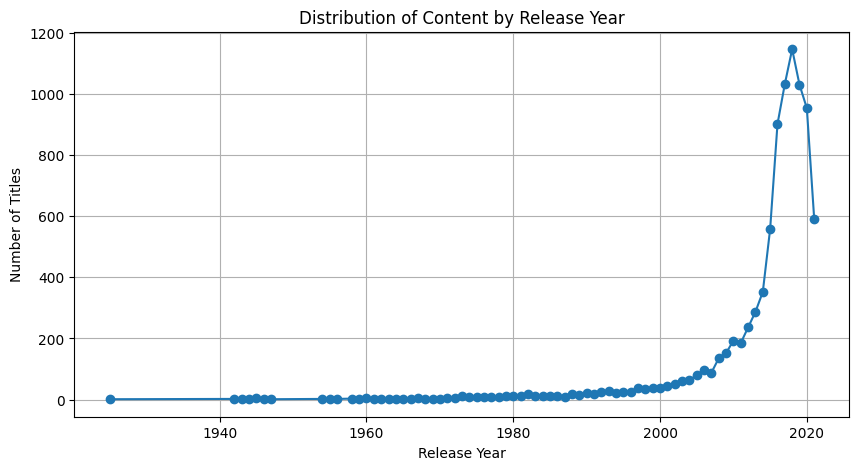

In [39]:
plt.figure(figsize=(10,5))

plt.plot(release_year.index, release_year.values, marker='o')

plt.title('Distribution of Content by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.grid(True)

plt.show()

### Observation

The dataset includes content released from **1925** to **2021**, which shows that Netflix has both old and new Movies and TV Shows. However, most of the content was released after **2000**, showing that Netflix mainly focuses on recent titles. The highest number of titles were released in **2018** (**1,146 titles**). After 2018, the number of released titles in the dataset decreased slightly.


## 4. Most Common Genres on Netflix

### Splitting Multiple Genres

Since a single title can belong to more than one genre, the `genres` column is split into separate rows using `explode()` to analyze each genre individually.


In [40]:
df_genres = df.copy()

df_genres['genres'] = df_genres['genres'].str.split(', ')

df_genres = df_genres.explode('genres')

In [41]:
df_genres['genres'].head()

0             Documentaries
1    International TV Shows
1                 TV Dramas
1              TV Mysteries
2            Crime TV Shows
Name: genres, dtype: str

In [42]:
df_genres.shape

(19303, 12)

In [43]:
genre_count = df_genres['genres'].value_counts()

genre_count.head(10)

genres
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

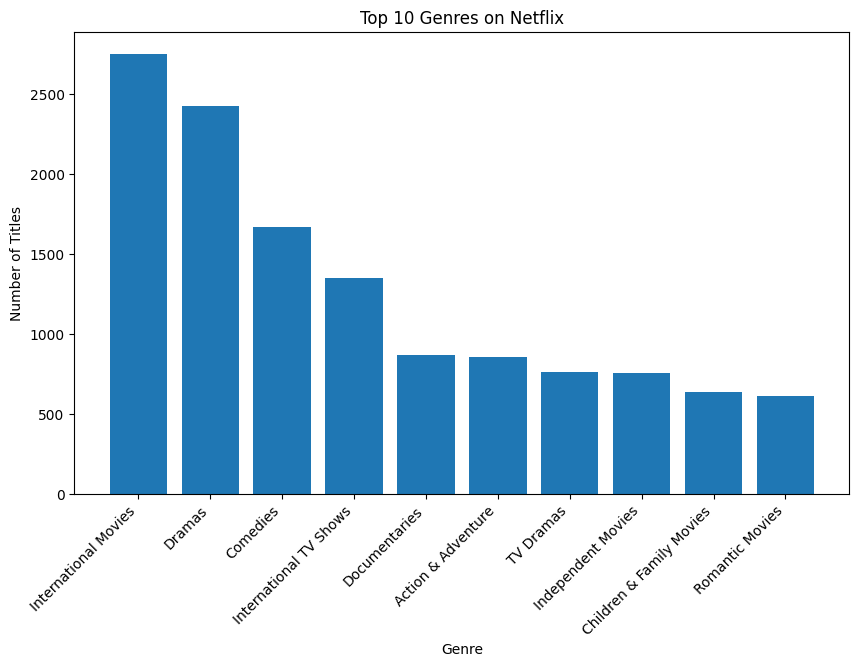

In [44]:
# Top 10 Most Common Genres
top_genres = genre_count.head(10)

plt.figure(figsize=(10,6))

plt.bar(top_genres.index, top_genres.values)

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45, ha='right')

plt.show()

## 5. Content Rating Distribution

In [45]:
# Count Ratings
rating_count = df['rating'].value_counts()

rating_count

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

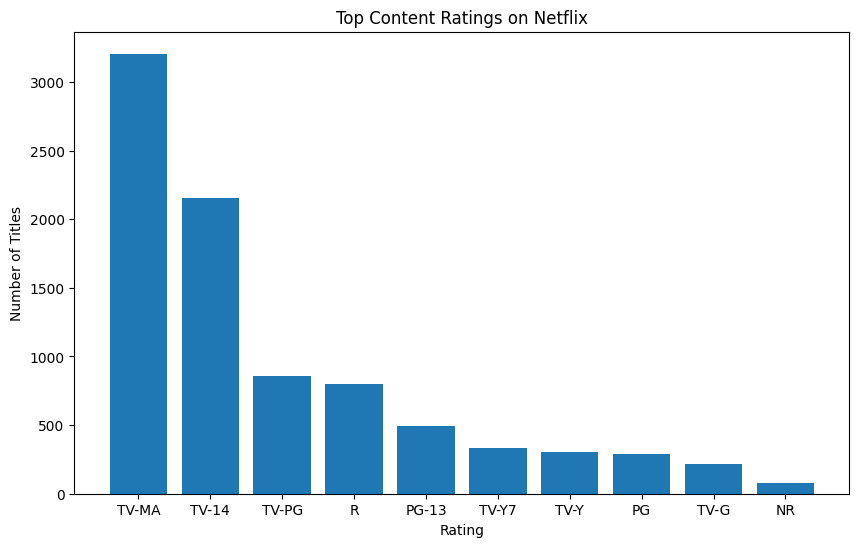

In [46]:
# Top 10 Content Ratings on Netflix
top_ratings = rating_count.head(10)

plt.figure(figsize=(10,6))

plt.bar(top_ratings.index, top_ratings.values)

plt.title('Top Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')

plt.show()

### Observation

The analysis shows that **TV-MA** is the most common rating on Netflix, followed by **TV-14** and **TV-PG**. This indicates that a large amount of Netflix content is targeted towards mature and teenage audiences. Ratings like **NC-17**, **UR**, and **TV-Y7-FV** have fewer titles compared to the most common ratings.


## 6. Content Distribution by Country

### Splitting Multiple Countries

Some titles are linked with more than one country. Therefore, the `country` column is split into separate rows to analyze each country separately.


In [47]:
df_country = df.copy()

df_country['country'] = df_country['country'].str.split(', ')

df_country = df_country.explode('country')

In [48]:
country_count = df_country['country'].value_counts()

country_count.head(10)

country
United States     3683
India             1046
Unknown            830
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

In [49]:
df_country.shape

(10835, 12)

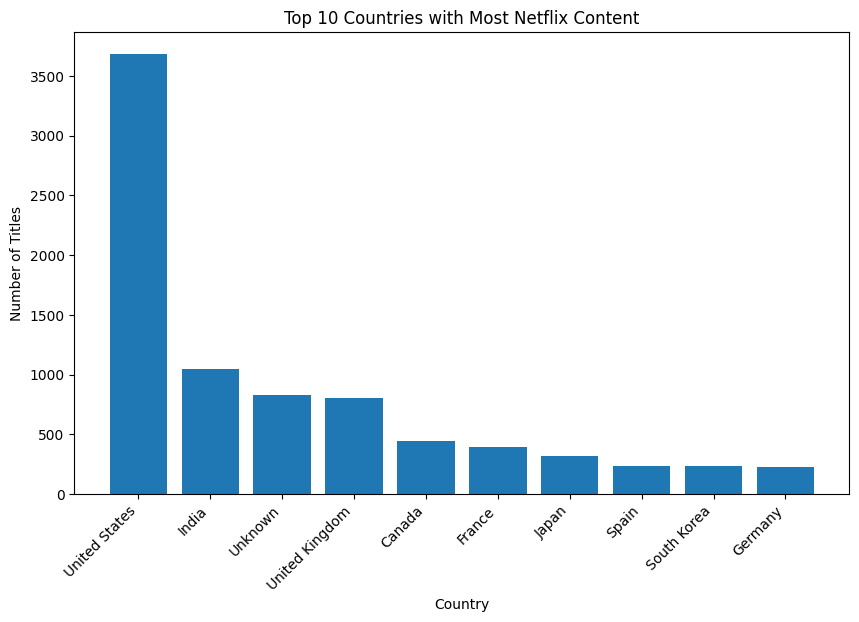

In [50]:
# Top 10 Countries with Most Netflix Content
top_countries = country_count.head(10)

plt.figure(figsize=(10,6))

plt.bar(top_countries.index, top_countries.values)

plt.title('Top 10 Countries with Most Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45, ha='right')

plt.show()

### Observation

The analysis shows that the **United States** has the highest number of titles on Netflix, followed by **India** and the **United Kingdom**. This indicates that Netflix has a large collection of content from these countries. Other countries like Canada, France, and Japan also contribute to Netflix's content library.


## 7. Content Duration Analysis

### 7.1 Movie Duration Analysis

In [51]:
#### Selecting Movies
movies = df[df['type'] == 'Movie'].copy()

In [52]:
#### Extracting Movie Duration in Minutes
movies['duration_minutes'] = movies['duration'].str.replace(' min','').astype(int)

In [53]:
#### Checking Movie Duration Data
movies[['title','duration','duration_minutes']].head()

,title,duration,duration_minutes
0,Dick Johnson Is Dead,90 min,90
6,My Little Pony: A New Generation,91 min,91
7,Sankofa,125 min,125
9,The Starling,104 min,104
12,Je Suis Karl,127 min,127


In [54]:
#### Movie Duration Summary
movies['duration_minutes'].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

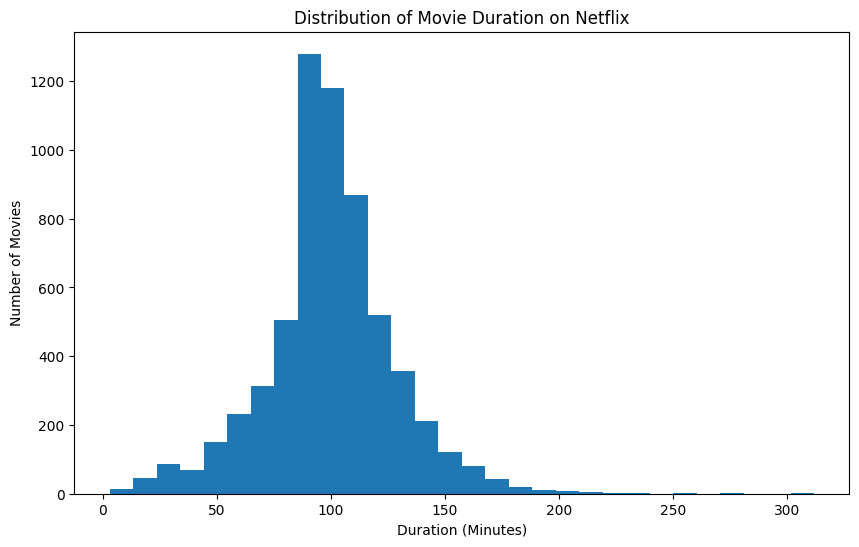

In [55]:
plt.figure(figsize=(10,6))

plt.hist(movies['duration_minutes'], bins=30)

plt.title('Distribution of Movie Duration on Netflix')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

plt.show()

### Observation

The analysis shows that the average movie duration on Netflix is around 100 minutes. Most movies have a duration between 87 and 114 minutes. The minimum duration is 3 minutes, while the maximum duration is 312 minutes, showing that Netflix contains movies with different lengths.


## 7.2 TV Show Season Analysis

In [56]:

# Selecting TV Shows
tv_shows = df[df['type'] == 'TV Show'].copy()

In [57]:
# Extracting Number of Seasons
tv_shows['seasons'] = tv_shows['duration'].str.replace(' Seasons','').str.replace(' Season','').astype(int)

In [58]:
# Checking Season Data
tv_shows[['title','duration','seasons']].head()

,title,duration,seasons
1,Blood & Water,2 Seasons,2
2,Ganglands,1 Season,1
3,Jailbirds New Orleans,1 Season,1
4,Kota Factory,2 Seasons,2
5,Midnight Mass,1 Season,1


In [59]:
# Season Distribution Summary
tv_shows['seasons'].describe()

count    2666.000000
mean        1.751313
std         1.550176
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: seasons, dtype: float64


The summary statistics show that there are **2,666 TV shows** with season information in the dataset. On average, a TV show has about **2 seasons**. Most TV shows have only **1 season**, and **75% of the shows have 2 or fewer seasons**. Only a few TV shows have many seasons, with the highest being **17 seasons**. This indicates that Netflix mainly offers short TV series rather than long-running shows.


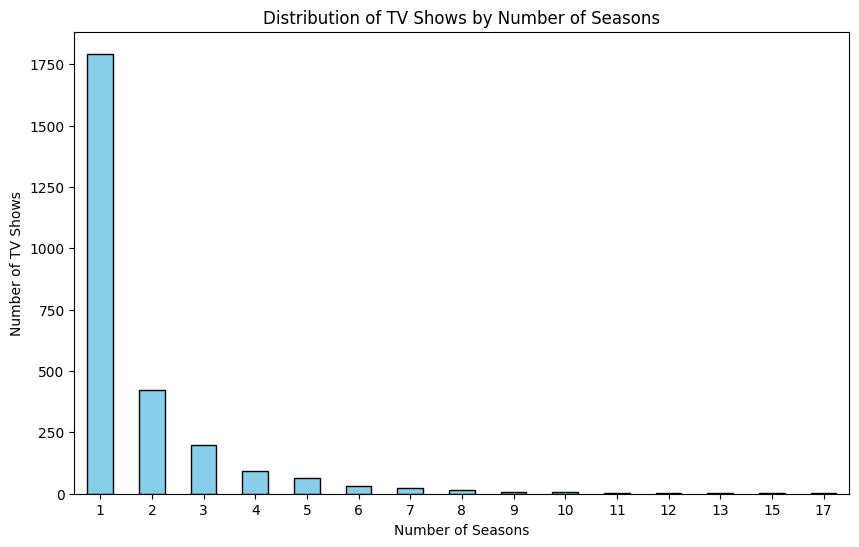

In [60]:
# Count the number of TV shows for each season count
season_counts = tv_shows['seasons'].value_counts().sort_index()

# Create the bar chart
plt.figure(figsize=(10,6))
season_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribution of TV Shows by Number of Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.xticks(rotation=0)

plt.show()

### Overall Insights from Univariate Analysis
The univariate analysis provides a clear overview of Netflix's content library by examining each variable individually. The analysis shows that Netflix offers a diverse collection of movies and TV shows, with movies making up a larger share of the platform. Most TV shows have one or two seasons, indicating that short series are more common. The dataset also highlights variations in genres, content ratings, release years, and content duration. Overall, the visualizations help in understanding the overall distribution and key characteristics of Netflix's content library.


### 5 Bivariate Analysis

Bivariate analysis was performed to examine the relationship between two variables in the Netflix dataset. This analysis helps identify patterns, comparisons, and trends that cannot be observed through univariate analysis alone.

## 5.1 Rating vs Type
 Objective: To compare the distribution of Movies and TV Shows across different content ratings on Netflix.

In [61]:
# Table (with Total)
table_data = pd.crosstab(df['type'], df['rating'], margins=True, margins_name='Total')
display(table_data)

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR,Unknown,Total
type,,,,,,,,,,,,,,,,
Movie,41,3,75,287,490,797,1427,126,2062,540,131,139,5,3,5,6131
TV Show,0,0,4,0,0,2,730,94,1143,321,175,194,1,0,2,2666
Total,41,3,79,287,490,799,2157,220,3205,861,306,333,6,3,7,8797


#### Tabular Analysis Observations
1.TV-MA is the most common content rating on Netflix, with 3,205 titles, followed by TV-14 with 2,157 titles.

2.Movies (6,131) are more numerous than TV Shows (2,666) across almost all content ratings.

3.TV-MA is the most common rating for both Movies (2,062) and TV Shows (1,143).

4.Ratings such as PG, PG-13, R, and NC-17 are almost entirely made up of Movies, with very few or no TV Shows.

5.Children's ratings such as TV-Y, TV-Y7, and TV-G include both Movies and TV Shows, but Movies are still slightly more common

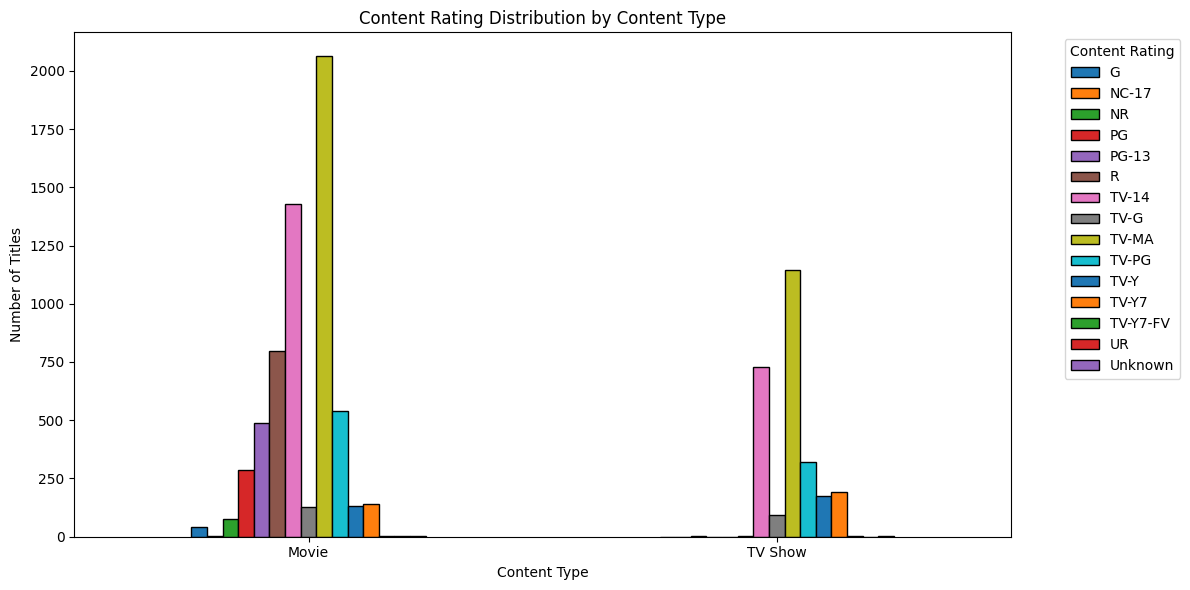

In [62]:
# Graph (without Total)
graph_data = pd.crosstab(df['type'], df['rating'])

graph_data.plot(kind='bar', figsize=(12,6), edgecolor='black')

plt.title('Content Rating Distribution by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)
plt.legend(title='Content Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Graph Analysis Observations
1.The graph clearly shows that TV-MA is the most common content rating for both Movies and TV Shows on Netflix.

2.TV-14 is the second most common rating, with a high number of both Movies and TV Shows.

3.Ratings such as PG, PG-13, R, and NC-17 are dominated by Movies, while very few or no TV Shows are available in these categories.

4.TV-specific ratings such as TV-PG, TV-Y, TV-Y7, and TV-G contain both Movies and TV Shows, but Movies generally have higher counts.

5.Overall, the graph shows that Movies dominate most content ratings, while TV Shows are mainly concentrated in TV-related rating categories.

## 5.2 Country vs Type
Objective:To analyze how Movies and TV Shows were added to Netflix over different years.

In [63]:
country_type = pd.crosstab(df['country'], df['type'])
country_type['Total'] = country_type.sum(axis=1)

top10_country_type = country_type.sort_values(
    by='Total',
    ascending=False
).head(10)

top10_country_type

type,Movie,TV Show,Total
country,,,
United States,2058,754,2812
India,893,79,972
Unknown,440,390,830
United Kingdom,206,212,418
Japan,76,168,244
South Korea,41,158,199
Canada,122,59,181
Spain,97,48,145
France,75,49,124


#### Tabular Analysis Observation
1.The United States has the highest number of Netflix titles (2,812), making it the largest content-producing country in the dataset.

2.India ranks second with 972 titles, and most of its content consists of Movies.

3.The Unknown category contains 830 titles, showing that some content does not have country information available in the dataset.

4.The United Kingdom has a nearly equal number of Movies (206) and TV Shows (212), indicating a balanced distribution of content.

5.Japan and South Korea have more TV Shows than Movies, while countries like Canada, Spain, France, and Mexico have a higher number of Movies than TV Shows.


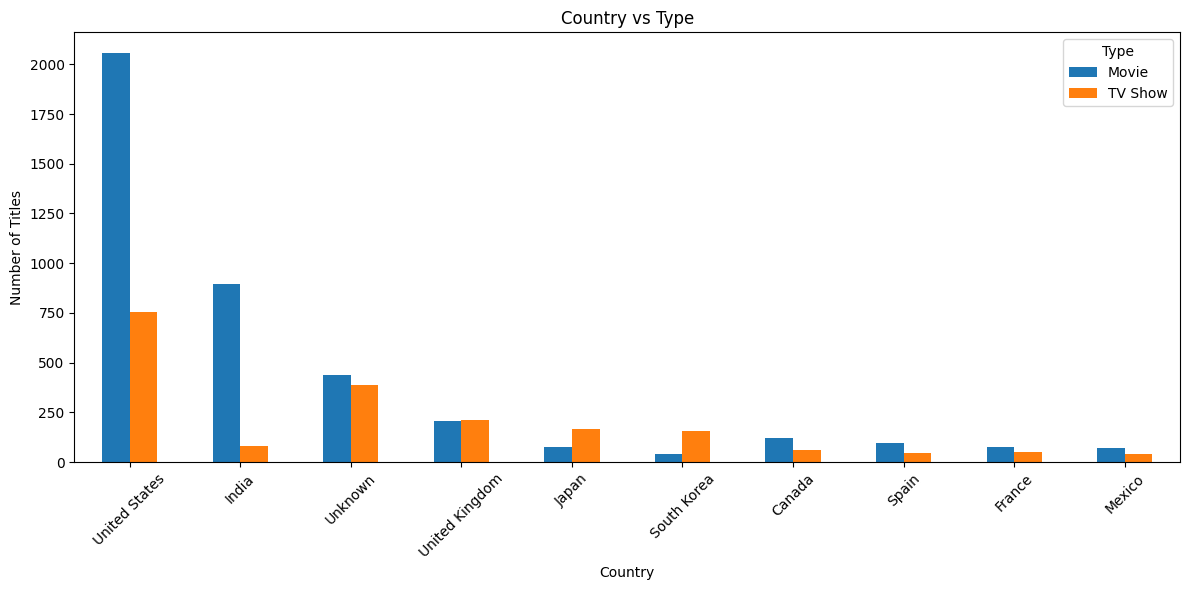

In [64]:
import matplotlib.pyplot as plt

top10_country_type.drop(columns='Total').plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Country vs Type')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.tight_layout()
plt.show()

#### Graph Analysis Observation
1.The graph clearly shows that the United States has the highest number of Netflix titles among all the top 10 countries.

2.India is the second-largest contributor, and most of its content consists of Movies rather than TV Shows.

3.The United Kingdom has a balanced distribution of Movies and TV Shows, with both content types available in almost equal numbers.

4.Japan and South Korea have more TV Shows than Movies, unlike most other countries in the graph.

5.Overall, the graph shows that Movies dominate Netflix content in most countries, while TV Shows are more prominent in only a few countries.

### Conclusion
The United States and India are the leading contributors to Netflix's content library, with Movies making up the majority of their titles. In contrast, countries like Japan, South Korea, and the United Kingdom have a stronger presence of TV Shows, reflecting different content production trends across countries.


## 5.3 Genre vs Type
Objective: To compare the distribution of Movies and TV Shows across the top 10 genres on Netflix.

In [65]:
# Reset index after explode
df_genres = df_genres.reset_index(drop=True)

genre_type = pd.crosstab(
    df_genres['genres'],
    df_genres['type']
)

genre_type['Total'] = genre_type.sum(axis=1)

top10_genre_type = (
    genre_type
    .sort_values(by='Total', ascending=False)
    .head(10)
)

top10_genre_type

type,Movie,TV Show,Total
genres,,,
International Movies,2752,0,2752
Dramas,2427,0,2427
Comedies,1674,0,1674
International TV Shows,0,1350,1350
Documentaries,869,0,869
Action & Adventure,859,0,859
TV Dramas,0,762,762
Independent Movies,756,0,756
Children & Family Movies,641,0,641


### Note:

Reason for Fix: The explode() function creates multiple rows from a single row while keeping the original index values. This can produce duplicate indices. Using reset_index(drop=True) creates a fresh unique index, preventing reindexing errors during pd.crosstab().

### Tabular Analysis Observations
1.International Movies has the highest number of titles (2,752), making it the most common genre on Netflix.

2.Dramas (2,427) and Comedies (1,674) are the next most popular genres.

3,Most of the top 10 genres are Movies, while only International TV Shows and TV Dramas belong to TV Shows.

4.Documentaries, Action & Adventure, Independent Movies, Children & Family Movies, and Romantic Movies are mainly available as Movies.

5.This table shows that Movies are available in more genres than TV Shows on Netflix.


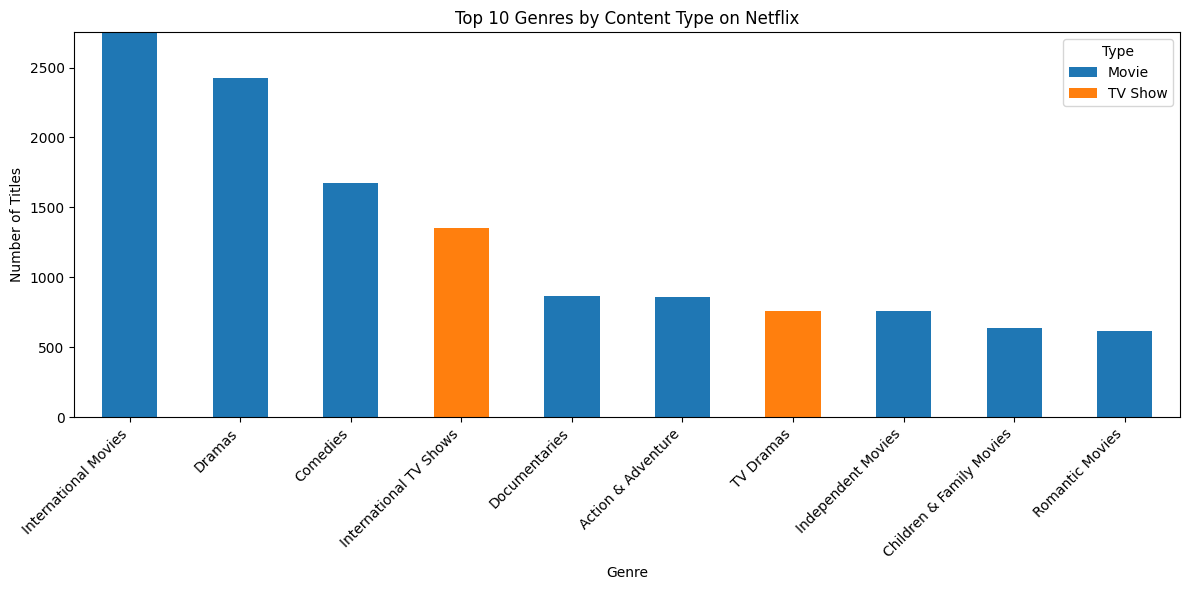

In [66]:
# Top 10 Genres vs Type
top10_genre_type.drop(columns='Total').plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Top 10 Genres by Content Type on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45, ha='right')

plt.legend(title='Type')

plt.tight_layout()

plt.show()

### Graph Analysis Observations
1.The graph clearly shows that International Movies has the largest number of titles among all genres.

2.Dramas and Comedies also have a high number of Movies compared to other genres.

3.International TV Shows and TV Dramas are the only genres with a large number of TV Shows in the top 10.

4.There is a clear difference between Movies and TV Shows, as most genres are dominated by Movies.

5.The graph makes it easy to compare the distribution of Movies and TV Shows across different genres.


###  Conclusion
Netflix mainly focuses on Movies, especially in genres like International Movies, Dramas, and Comedies. On the other hand, TV Shows are mostly concentrated in TV-specific genres such as International TV Shows and TV Dramas. Overall, the platform offers a much wider variety of Movies than TV Shows.

## 5.4 added_year vs type
Objective :To analyze how Movies and TV Shows were added to Netflix over different years.

In [67]:
added_type = pd.crosstab(df['added_year'], df['type'])

added_type['Total'] = added_type.sum(axis=1)

added_type

type,Movie,TV Show,Total
added_year,,,
2008,1,1,2
2009,2,0,2
2010,1,0,1
2011,13,0,13
2012,3,0,3
2013,6,5,11
2014,19,5,24
2015,56,26,82
2016,253,176,429


### Tabular Analysis Observations
1.Netflix added very few titles between 2008 and 2014, showing slow growth in the early years.

2.From 2015 onwards, the number of Movies and TV Shows added increased rapidly.

3.2019 has the highest number of content additions (2,016 titles), making it the most active year.

4.In every year, the number of Movies added is higher than the number of TV Shows.

5.After 2019, the total number of titles added decreased slightly in 2020 and 2021, but Movies still remained the dominant content type.


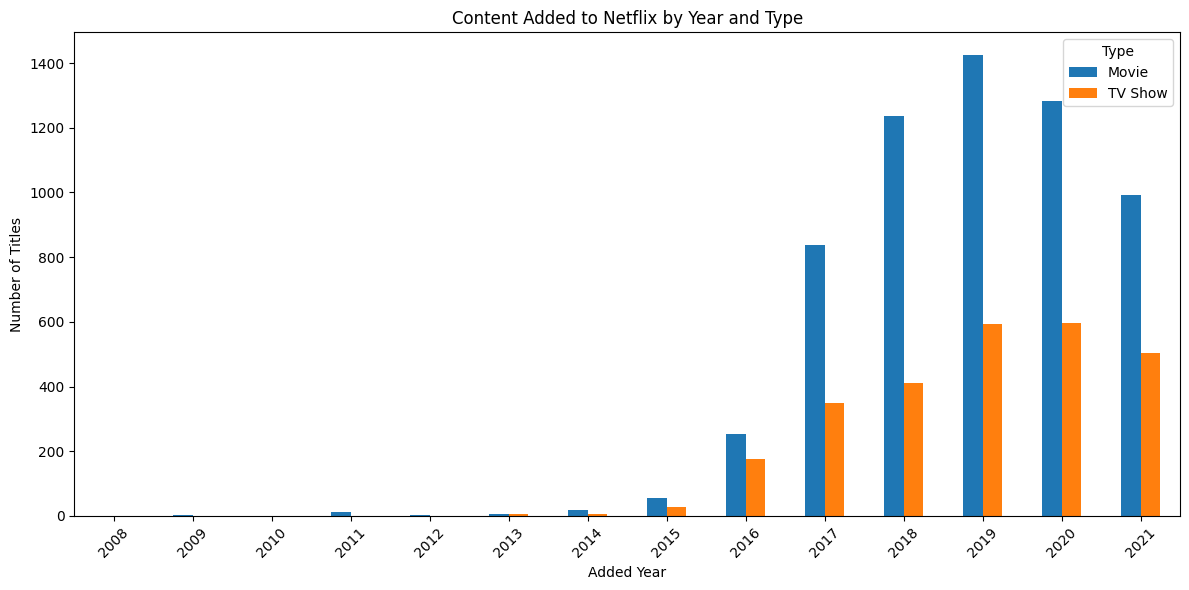

In [68]:
added_type[['Movie', 'TV Show']].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Content Added to Netflix by Year and Type')
plt.xlabel('Added Year')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.legend(title='Type')

plt.tight_layout()

plt.show()

### Graph Analysis Observations
1.The graph shows a steady increase in content additions from 2015 to 2019.
    
2.Movies have consistently been added in larger numbers than TV Shows throughout the years.
    
3.The highest peak is seen in 2019, where both Movies and TV Shows reached their maximum additions.
    
4.Although content additions declined after 2019, Netflix continued to add a large number of Movies and TV Shows.
    
5.The graph clearly highlights Netflix's rapid content expansion after 2015.

### Conclusion

Netflix expanded its content library significantly after 2015, with the highest number of titles added in 2019. Movies were consistently added in greater numbers than TV Shows, showing that Netflix focused more on Movies while steadily increasing its TV Show collection over the years.

## 5.5 Rating vs Average duration
Objective: To analyze the average duration of Movies across different content ratings on Netflix.

In [69]:
# Create a Movie dataset
movie_df = df[df['type'] == 'Movie'].copy()

# Convert duration to numeric
movie_df['duration'] = movie_df['duration'].str.replace(' min', '', regex=False).astype(int)

# Average Duration and Movie Count by Rating
rating_duration = (
    movie_df.groupby('rating')
    .agg(
        Average_Duration=('duration', 'mean'),
        Movie_Count=('duration', 'count')
    )
    .round(1)
    .sort_values(by='Average_Duration', ascending=False)
)

rating_duration

,Average_Duration,Movie_Count
rating,,
NC-17,125.0,3
TV-14,110.3,1427
PG-13,108.3,490
R,106.7,797
UR,106.3,3
PG,98.3,287
TV-MA,95.9,2062
TV-PG,94.9,540
NR,94.5,75


### Tabular Analysis Observations
1.NC-17 has the highest average movie duration (125 minutes), but it contains only 3 movies, so this average is based on a very small number of titles.

2.TV-14, PG-13, and R rated movies also have a high average duration, with more than 100 minutes on average.

3.TV-MA has the highest number of movies (2,062), with an average duration of about 96 minutes.

4.Movies with children's ratings such as TV-Y, TV-Y7, and TV-G have shorter average durations compared to other ratings.

5.Ratings with a very small movie count (such as UR, Unknown, and TV-Y7-FV) may have average durations that are less representative of the overall dataset.

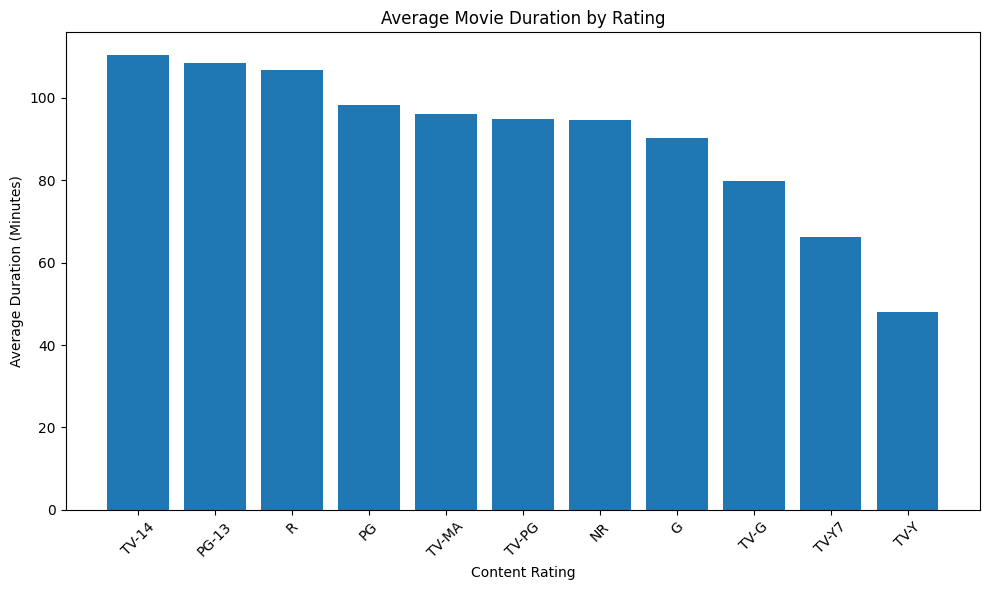

In [70]:
rating_duration_filtered = rating_duration[
    rating_duration['Movie_Count'] >= 30
]

plt.figure(figsize=(10,6))

plt.bar(
    rating_duration_filtered.index,
    rating_duration_filtered['Average_Duration']
)

plt.title('Average Movie Duration by Rating')
plt.xlabel('Content Rating')
plt.ylabel('Average Duration (Minutes)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Note: The graph includes only ratings with 30 or more movies. Ratings with very few movies were excluded to provide a more reliable comparison of average movie duration.

### Graph Analysis Observations
1.The graph shows that the average movie duration is different for each content rating.

2.NC-17 has the highest average duration (125 minutes), but it has only 3 movies, so this result is based on a very small number of titles.

3.Popular ratings such as TV-14, PG-13, and R have longer average movie durations, generally above 100 minutes.

4.Children's ratings like TV-Y, TV-Y7, and TV-G have shorter average movie durations than other ratings.

5.TV-MA has the highest number of movies (2,062) with an average duration of about 96 minutes, making it one of the most common and reliable ratings in the dataset.

## Key Insights
1.Movies dominate Netflix's catalog, making up the majority of the content across almost every category, including ratings, genres, countries, and years.

2.The United States is the largest content producer, followed by India, while countries like Japan and South Korea contribute more TV Shows than Movies.

3.Netflix's content library grew rapidly after 2015, with 2019 being the year when the highest number of titles was added.

4.Most Netflix titles were released between 2016 and 2020, showing that the platform mainly focuses on recent content while still offering some older titles.

5.International Movies, Dramas, and Comedies are the most popular genres, indicating a strong preference for movie-based entertainment.

6.TV-MA is the most common content rating on Netflix, followed by TV-14 and TV-PG. This shows that Netflix mainly focuses on content for mature and teenage audiences.

7.Movies are available in a wider variety of genres and ratings than TV Shows, highlighting Netflix's greater investment in movie content.

8.Most movies have a duration of around 100 minutes, while children's movies are generally shorter than movies intended for older audiences
.
9.Most TV Shows have only one season, indicating that limited-series and short-format shows are common on Netflix.

10.Overall, the analysis shows that Netflix primarily focuses on providing a diverse collection of modern movies, while also maintaining a significant selection of TV Shows across different countries, genres, and audience ratings.

## Conclusion

This project explored the Netflix dataset using Python to identify trends in content type, genres, ratings, release years, and countries. The analysis shows that Netflix's catalog is dominated by Movies, with significant growth in content additions after 2015. The United States and India contribute the largest share of titles, while TV-MA is the most common content rating. Overall, this project demonstrates the use of data cleaning, visualization, and exploratory data analysis (EDA) to extract meaningful insights from a real-world dataset.

## Export Cleaned Dataset

In [71]:
# Save the cleaned dataset
df.to_csv('netflix_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [72]:
df_exploded = df.copy()

df_exploded['genres'] = df_exploded['genres'].str.split(', ')
df_exploded = df_exploded.explode('genres')

df_exploded['country'] = df_exploded['country'].str.split(', ')
df_exploded = df_exploded.explode('country')

In [73]:
df_exploded.to_csv("Netflix_Exploded.csv", index=False)
print("Exploded dataset saved successfully!")

Exploded dataset saved successfully!
